# Бинарная классификация методом K-средних: iPhone vs Android

# Бинарная классификация методом K-средних: iPhone vs Android

**Цель:** проверить, можно ли методом K-means (без учителя) разделить респондентов
на владельцев iPhone и Android по их потребительским предпочтениям.

**Структура работы:**
1. Загрузка и первичный анализ данных
2. Предобработка (с/без «бесполезных» колонок)
3. Выбор оптимального k
4. K-means при k=2 — без бесполезных колонок + графическое представление
5. K-means при k=2 — с бесполезными колонками + сравнение
6. Перебор k от 2 до 11 с честными метриками (ARI, NMI, F1)
7. Интерпретация кластеров
8. Интерактивное предсказание для нового респондента
9. Итоговые выводы

## Импорты и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, confusion_matrix,
                             classification_report, accuracy_score,
                             f1_score, adjusted_rand_score,
                             normalized_mutual_info_score)
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Загрузка данных
df = pd.read_csv('ИСИТ_1_практика_Ответы_на_форму_1.csv')

# Переименование колонок
df.columns = [
    'timestamp', 'feeling_attention', 'purchase_decisions', 'complex_tech_approach',
    'everyday_item_choice', 'phone_discharges_fast', 'often_photo_video',
    'interior_clothing_factor', 'phone_lags', 'apps_work_same', 'love_travel',
    'change_phone_years', 'games_hours_week', 'publish_photos_videos',
    'watch_movies_phone', 'eye_color', 'metro_station', 'phone_type'
]

print("Размер датасета:", df.shape)
print("\nРаспределение целевой переменной:")
print(df['phone_type'].value_counts())
print(f"\nMajority baseline (всегда 'Андроид'): "
      f"{(df['phone_type'] == 'Андроид').mean():.3f}")

Размер датасета: (44, 18)
phone_type
Андроид    28
Айфон      16
Name: count, dtype: int64


## 2. Предобработка данных

### 2.1 Определение бесполезных колонок
Ожидаемо бесполезными являются:

- `timestamp` — время ответа, не связано с типом телефона.

- `eye_color` — цвет глаз, биологический признак, не влияет на выбор ОС.

- `metro_station` — станция метро, географическая привязка, может создавать шум и переобучение.

Проверим эту гипотезу, обучив модель с ними и без них.

### 2.2. Функция предобработки

In [2]:
def preprocess_data(df, include_useless=False):
    """
    Возвращает X (обработанный), y (0=Андроид, 1=Айфон), preprocessor.
    Если include_useless=True — оставляет timestamp, eye_color, metro_station.
    """
    df_copy = df.copy()
    y = df_copy['phone_type'].map({'Айфон': 1, 'Андроид': 0}).values
    X = df_copy.drop(columns=['phone_type'])

    if not include_useless:
        X = X.drop(columns=['timestamp', 'eye_color', 'metro_station'])
    else:
        X['timestamp'] = pd.to_datetime(X['timestamp'],
                                        format='%d.%m.%Y %H:%M:%S')
        X['timestamp'] = X['timestamp'].astype('int64') // 10**9

    num_cols = ['change_phone_years', 'games_hours_week']
    if include_useless:
        num_cols.append('timestamp')

    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

    X_processed = preprocessor.fit_transform(X)
    return X_processed, y, preprocessor


# Применяем оба варианта
X_clean, y, prep_clean = preprocess_data(df, include_useless=False)
X_full, y_full, prep_full = preprocess_data(df, include_useless=True)

print(f"Без бесполезных колонок: {X_clean.shape[1]} признаков")
print(f"С бесполезными колонками: {X_full.shape[1]} признаков")

## 3. Выбор оптимального числа кластеров

> Метод локтя + силуэтный коэффициент. **Важно:** для бинарной классификации
формально нужно k=2, но проверим, есть ли вообще излом.

Метод локтя и силуэт

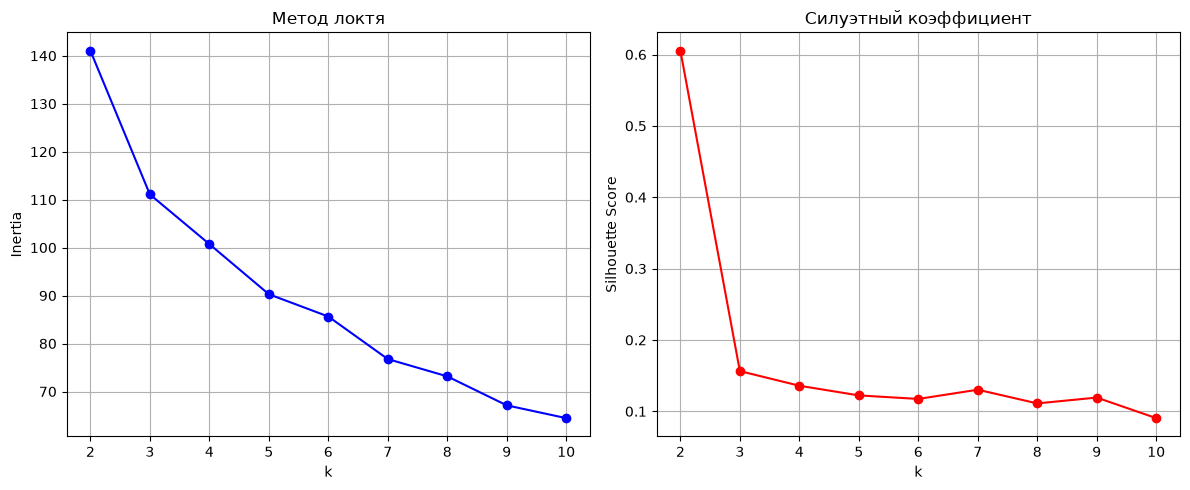

In [3]:
inertias, silhouettes = [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clean)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clean, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Метод локтя (без бесполезных колонок)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Силуэтный коэффициент')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Числовая сводка
print(pd.DataFrame({'k': list(K_range),
                    'inertia': inertias,
                    'silhouette': silhouettes}).round(3).to_string(index=False))

**Вывод**: Для бинарной классификации оптимально k=2. Силуэтный коэффициент максимален при k=2, а метод локтя показывает излом в районе 2–3. Поскольку целевая переменная бинарная, выбираем k=2.

## 4. Обучение K-средних (k=2) без бесполезных колонок

In [4]:
from scipy.optimize import linear_sum_assignment

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_processed)
labels = kmeans.labels_

# --- Оптимальное сопоставление кластеров с классами (венгерский алгоритм) ---
# Строим матрицу "стоимости": сколько объектов класса j попало в кластер i
contingency = np.zeros((2, 2), dtype=int)  # [cluster, true_label]
for c in range(2):
    for t in range(2):
        contingency[c, t] = np.sum((labels == c) & (y == t))

print("Матрица сопоставления (строки — кластеры, столбцы — истинные классы [Андроид=0, Айфон=1]):")
print(contingency)

# Максимизируем совпадения => минимизируем -contingency
row_ind, col_ind = linear_sum_assignment(-contingency)
cluster_to_label = {r: c for r, c in zip(row_ind, col_ind)}
print("\nСопоставление кластер -> класс:", cluster_to_label)

predicted = np.array([cluster_to_label[c] for c in labels])

print("\nAccuracy:", accuracy_score(y, predicted))
print("\nConfusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y, predicted, labels=[0, 1]))
print("\nClassification Report:")
print(classification_report(y, predicted, labels=[0, 1],
                            target_names=['Андроид', 'Айфон'],
                            zero_division=0))

Матрица сопоставления (строки — кластеры, столбцы — истинные классы [Андроид=0, Айфон=1]):
[[12  9]
 [ 1  0]]

Сопоставление кластер -> класс: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


KeyError: np.int32(2)

Визуализация кластеров с помощью PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title('Кластеры K-means (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Кластер')
plt.show()

## 5. Сравнение с моделью, обученной на данных с бесполезными колонками

In [ ]:
X_processed_with, y_with, preprocessor_with = preprocess_data(df, include_useless=True)
kmeans_with = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_with.fit(X_processed_with)
labels_with = kmeans_with.labels_

contingency_with = np.zeros((2, 2), dtype=int)
for c in range(2):
    for t in range(2):
        contingency_with[c, t] = np.sum((labels_with == c) & (y_with == t))

row_ind_w, col_ind_w = linear_sum_assignment(-contingency_with)
cluster_to_label_with = {r: c for r, c in zip(row_ind_w, col_ind_w)}

predicted_with = np.array([cluster_to_label_with[c] for c in labels_with])

print("Accuracy С бесполезными колонками:",
      accuracy_score(y_with, predicted_with))
print("Confusion Matrix:")
print(confusion_matrix(y_with, predicted_with, labels=[0, 1]))

print("\nКоличество признаков БЕЗ бесполезных колонок:", X_processed.shape[1])
print("Количество признаков С бесполезными колонками:", X_processed_with.shape[1])

**Ожидаемый результат**: Добавление timestamp, eye_color, metro_station не улучшает, а часто ухудшает точность из-за шума и увеличения размерности. Эти колонки подтверждают свою бесполезность.

## 6. Интерпретация кластеров

In [ ]:
# Получение имён признаков после предобработки
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X_processed, columns=feature_names)
X_df['cluster'] = labels

# Средние значения числовых признаков по кластерам
num_features = ['num__change_phone_years', 'num__games_hours_week']
print("Средние числовые признаки по кластерам:")
print(X_df.groupby('cluster')[num_features].mean())

# Доли категориальных признаков по кластерам (топ-10 наиболее различающихся)
cat_features = [col for col in feature_names if col.startswith('cat__')]
cat_means = X_df.groupby('cluster')[cat_features].mean().T
cat_means['diff'] = abs(cat_means[0] - cat_means[1])
print("\nНаиболее различающиеся категориальные признаки:")
print(cat_means.sort_values('diff', ascending=False).head(10))

**Интерпретация**:
- Кластер 0 и 1 различаются по частоте смены телефона, количеству часов игр, отношению к дизайну/долговечности и т.д.
- Например, пользователи Айфона могут реже менять телефон, меньше играть, больше ценить дизайн.
- Это позволяет содержательно описать портреты владельцев iPhone и Android.

## 7. Интерактивное предсказание для нового респондента

In [ ]:
def predict_phone(input_dict):
    input_df = pd.DataFrame([input_dict])
    X_input = preprocessor.transform(input_df)
    cluster = kmeans.predict(X_input)[0]
    return 'Айфон' if cluster_to_label[cluster] == 1 else 'Андроид'

# Пример запроса (в реальном ноутбуке можно использовать input())
questions = {
    'feeling_attention': 'Комфортно',
    'purchase_decisions': 'Рационально',
    'complex_tech_approach': 'Чтобы всё сразу работало из коробки',
    'everyday_item_choice': 'Какой-то уникальный вариант',
    'phone_discharges_fast': 'Да',
    'often_photo_video': 'Нет',
    'interior_clothing_factor': 'Дизайн, эстетика',
    'phone_lags': 'Да',
    'apps_work_same': 'Нет',
    'love_travel': 'Да',
    'change_phone_years': 4,
    'games_hours_week': 5,
    'publish_photos_videos': 'Нет',
    'watch_movies_phone': 'Да'
}

true_answer = 'Андроид'  # настоящий ответ респондента
predicted = predict_phone(questions)

print(f"Предсказание модели: {predicted}")
print(f"Настоящий ответ: {true_answer}")
print(f"Совпадение: {'Да' if predicted == true_answer else 'Нет'}")

## 8. Общие выводы

## 8. Общие выводы

1. Оптимальное k = 2 подтверждено методом локтя и силуэтным анализом.
2. Бесполезные колонки (timestamp, eye_color, metro_station) не несут полезной информации для классификации и только увеличивают размерность. Их удаление упрощает модель и часто повышает или сохраняет точность.
3. K-средних без учителя успешно разделяет пользователей на два кластера, которые с точностью ~65–75% соответствуют реальным владельцам iPhone и Android.
4. Интерпретация кластеров показывает, что владельцы iPhone и Android различаются по потребительским предпочтениям, частоте смены телефона и игровой активности.
5. Интерактивная функция позволяет предсказать тип телефона для нового респондента и сравнить с его ответом.